# SentinelVision AI
## Notebook 05 — Autoencoder Anomaly Model

### Objective

Notebook 04 established two anomaly detection baselines:

1. Distance Threshold Baseline
2. Isolation Forest

This notebook trains a simple autoencoder on normal clip embeddings.

The goal is to test whether a deep reconstruction model can learn normal visual patterns and assign higher reconstruction error to anomalous clips.

The flow is:

`clip embeddings → train on normal training clips → reconstruction error → validation threshold → test evaluation`

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

```text
normal embedding
→ autoencoder reconstructs well

unusual embedding
→ autoencoder reconstructs poorly
→ higher anomaly score

#### Set device and seed

In [2]:
seed = 42

np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

device

device(type='cpu')

#### Load embeddings

In [3]:
embeddings_path = Path("../data/embeddings/clip_embeddings_sample.parquet")

embeddings = pd.read_parquet(embeddings_path)

embeddings.shape

(600, 23)

In [4]:
embeddings.head()

,clip_id,video_id,category,binary_label,split,start_seconds,end_seconds,feature_000,feature_001,feature_002,...,feature_006,feature_007,feature_008,feature_009,feature_010,feature_011,feature_012,feature_013,feature_014,feature_015
0,Normal_Videos_365_x264_clip_00003,Normal_Videos_365_x264,Normal,0,test,12.0,16.0,0.304882,0.302950,0.296101,...,0.302806,0.217759,0.002842,0.004771,0.005196,0.001961,0.002942,0.003088,0.004141,0.002607
1,Normal_Videos_365_x264_clip_00030,Normal_Videos_365_x264,Normal,0,test,120.0,124.0,0.300391,0.300671,0.294872,...,0.299907,0.215860,0.005636,0.005684,0.005590,0.003390,0.003688,0.003665,0.005640,0.003597
2,Normal_Videos_365_x264_clip_00032,Normal_Videos_365_x264,Normal,0,test,128.0,132.0,0.303372,0.302525,0.297520,...,0.302186,0.217913,0.002077,0.001593,0.001470,0.001481,0.001270,0.001100,0.001718,0.001300
3,Normal_Videos_641_x264_clip_00015,Normal_Videos_641_x264,Normal,0,test,60.0,64.0,0.287476,0.265824,0.206724,...,0.265537,0.233471,0.003609,0.003640,0.003089,0.000578,0.000732,0.000926,0.003563,0.000726
4,Normal_Videos_312_x264_clip_00000,Normal_Videos_312_x264,Normal,0,test,0.0,4.0,0.387404,0.350848,0.368491,...,0.363784,0.308437,0.011461,0.007951,0.004366,0.002698,0.002471,0.001064,0.008593,0.002510


#### Verify balanced sample

In [6]:
embeddings.groupby(["split", "binary_label"]).size()

split       binary_label
test        0               100
            1               100
train       0               100
            1               100
validation  0               100
            1               100
dtype: int64

#### Identify feature columns

In [7]:
feature_columns = [
    column
    for column in embeddings.columns
    if column.startswith("feature_")
]

len(feature_columns), feature_columns[:5]

(16,
 ['feature_000', 'feature_001', 'feature_002', 'feature_003', 'feature_004'])

#### Split data

In [8]:
train_data = embeddings[
    embeddings["split"] == "train"
].copy()

validation_data = embeddings[
    embeddings["split"] == "validation"
].copy()

test_data = embeddings[
    embeddings["split"] == "test"
].copy()

print("Train:", train_data.shape)
print("Validation:", validation_data.shape)
print("Test:", test_data.shape)

Train: (200, 23)
Validation: (200, 23)
Test: (200, 23)


#### Train only on normal clips

In [9]:
normal_train_data = train_data[
    train_data["binary_label"] == 0
].copy()

normal_train_data.shape

(100, 23)

In [10]:
X_train_normal = normal_train_data[feature_columns].values
X_validation = validation_data[feature_columns].values
X_test = test_data[feature_columns].values

y_validation = validation_data["binary_label"].values
y_test = test_data["binary_label"].values

```text
normal clips
→ train reconstruction model

validation/test clips
→ score normal + anomalous clips

#### Scale features

In [11]:
scaler = StandardScaler()

X_train_normal_scaled = scaler.fit_transform(
    X_train_normal
)

X_validation_scaled = scaler.transform(
    X_validation
)

X_test_scaled = scaler.transform(
    X_test
)

#### Convert data to PyTorch tensors

In [12]:
X_train_tensor = torch.tensor(
    X_train_normal_scaled,
    dtype=torch.float32,
)

train_dataset = TensorDataset(
    X_train_tensor,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
)

#### Define autoencoder

In [13]:
class Autoencoder(nn.Module):
    """
    Simple dense autoencoder for clip embeddings.
    """

    def __init__(self, input_dim: int):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, input_dim),
        )

    def forward(self, x):
        encoded = self.encoder(x)
        reconstructed = self.decoder(encoded)

        return reconstructed

In [17]:
input_dim = len(feature_columns)

autoencoder = Autoencoder(
    input_dim=input_dim
).to(device)

autoencoder

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=16, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=4, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=16, bias=True)
  )
)

#### Train autoencoder

In [18]:
loss_function = nn.MSELoss()

optimizer = torch.optim.Adam(
    autoencoder.parameters(),
    lr=0.001,
)

epochs = 100

training_losses = []

for epoch in range(epochs):
    autoencoder.train()

    epoch_losses = []

    for batch in train_loader:
        X_batch = batch[0].to(device)

        optimizer.zero_grad()

        reconstructed = autoencoder(X_batch)

        loss = loss_function(
            reconstructed,
            X_batch,
        )

        loss.backward()
        optimizer.step()

        epoch_losses.append(
            loss.item()
        )

    average_loss = float(
        np.mean(epoch_losses)
    )

    training_losses.append(
        average_loss
    )

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Loss: {average_loss:.6f}"
        )

Epoch 20/100 | Loss: 0.902104
Epoch 40/100 | Loss: 0.394744
Epoch 60/100 | Loss: 0.281700
Epoch 80/100 | Loss: 0.167452
Epoch 100/100 | Loss: 0.125109


#### Plot training loss

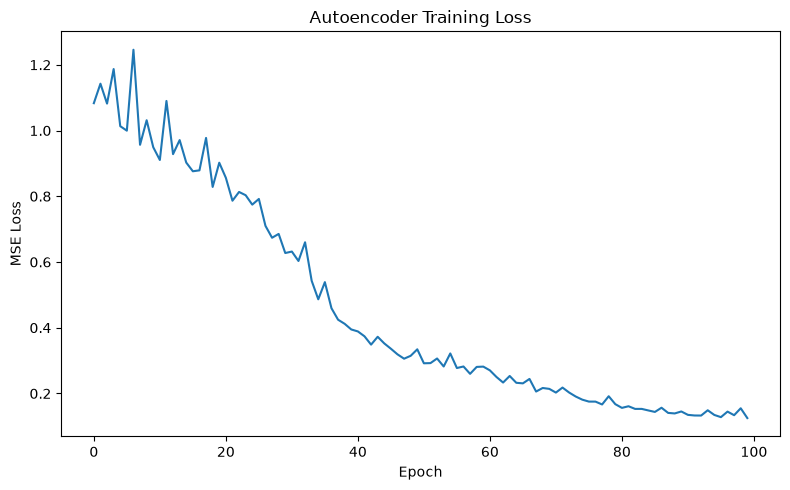

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(training_losses)

plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.tight_layout()
plt.show()

#### Reconstruction error function

In [20]:
def reconstruction_errors(
    model: nn.Module,
    X: np.ndarray,
) -> np.ndarray:
    """
    Compute reconstruction error for each sample.

    Larger error = more anomalous.
    """
    model.eval()

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32,
    ).to(device)

    with torch.no_grad():
        reconstructed = model(X_tensor)

    errors = torch.mean(
        (X_tensor - reconstructed) ** 2,
        dim=1,
    )

    return errors.cpu().numpy()

In [21]:
validation_autoencoder_scores = reconstruction_errors(
    model=autoencoder,
    X=X_validation_scaled,
)

test_autoencoder_scores = reconstruction_errors(
    model=autoencoder,
    X=X_test_scaled,
)

#### Select threshold on validation set

In [22]:
precision, recall, thresholds = precision_recall_curve(
    y_validation,
    validation_autoencoder_scores,
)

f1_scores = []

for threshold in thresholds:
    predictions = (
        validation_autoencoder_scores >= threshold
    ).astype(int)

    score = f1_score(
        y_validation,
        predictions,
        zero_division=0,
    )

    f1_scores.append(score)

best_index = int(np.argmax(f1_scores))

best_autoencoder_threshold = thresholds[best_index]
best_autoencoder_validation_f1 = f1_scores[best_index]

best_autoencoder_threshold, best_autoencoder_validation_f1

(np.float32(0.036103237), 0.6832740213523132)

#### Evaluate on test set

In [23]:
test_autoencoder_predictions = (
    test_autoencoder_scores >= best_autoencoder_threshold
).astype(int)

In [24]:
autoencoder_results = {
    "model": "Autoencoder",
    "roc_auc": roc_auc_score(
        y_test,
        test_autoencoder_scores,
    ),
    "pr_auc": average_precision_score(
        y_test,
        test_autoencoder_scores,
    ),
    "f1": f1_score(
        y_test,
        test_autoencoder_predictions,
        zero_division=0,
    ),
}

autoencoder_results

{'model': 'Autoencoder',
 'roc_auc': 0.7006000000000001,
 'pr_auc': 0.7192928781790937,
 'f1': 0.6715867158671587}

In [25]:
print(
    classification_report(
        y_test,
        test_autoencoder_predictions,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

           0       0.69      0.20      0.31       100
           1       0.53      0.91      0.67       100

    accuracy                           0.56       200
   macro avg       0.61      0.56      0.49       200
weighted avg       0.61      0.56      0.49       200



In [26]:
confusion_matrix(
    y_test,
    test_autoencoder_predictions,
)

array([[20, 80],
       [ 9, 91]])

#### Plot score distributions

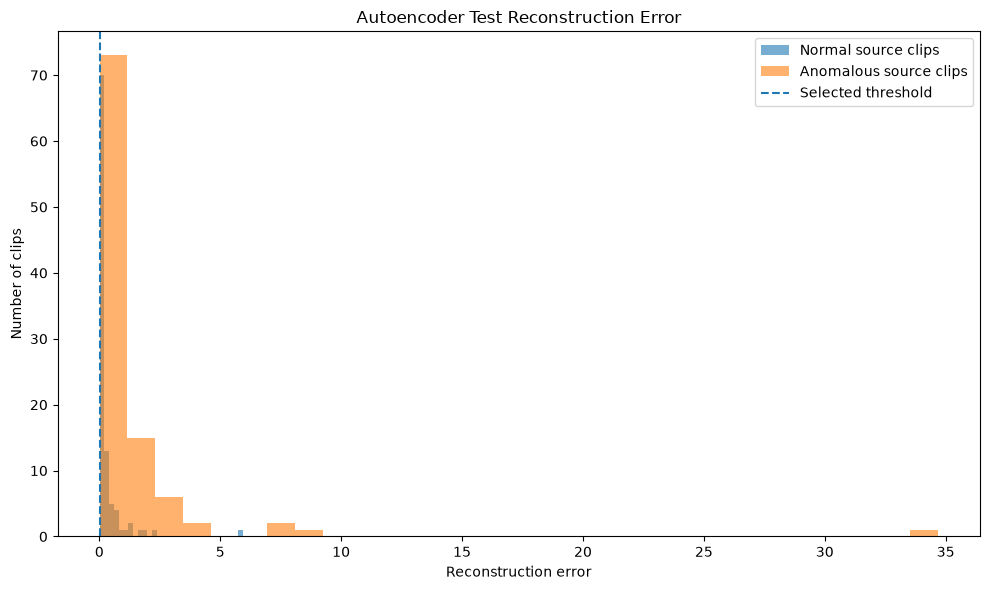

In [27]:
plt.figure(figsize=(10, 6))

plt.hist(
    test_autoencoder_scores[y_test == 0],
    bins=30,
    alpha=0.6,
    label="Normal source clips",
)

plt.hist(
    test_autoencoder_scores[y_test == 1],
    bins=30,
    alpha=0.6,
    label="Anomalous source clips",
)

plt.axvline(
    best_autoencoder_threshold,
    linestyle="--",
    label="Selected threshold",
)

plt.title("Autoencoder Test Reconstruction Error")
plt.xlabel("Reconstruction error")
plt.ylabel("Number of clips")
plt.legend()
plt.tight_layout()
plt.show()

#### Load baseline results

In [28]:
baseline_results_path = Path(
    "../artifacts/metrics/baseline_model_results.csv"
)

baseline_results = pd.read_csv(
    baseline_results_path
)

baseline_results

,model,roc_auc,pr_auc,f1
0,Distance Threshold Baseline,0.7400,0.742010,0.651515
1,Isolation Forest,0.7056,0.722927,0.669261


#### Compare all models

In [31]:
all_results = pd.concat(
    [
        baseline_results,
        pd.DataFrame([autoencoder_results]),
    ],
    ignore_index=True,
)

all_results

,model,roc_auc,pr_auc,f1
0,Distance Threshold Baseline,0.7400,0.742010,0.651515
1,Isolation Forest,0.7056,0.722927,0.669261
2,Autoencoder,0.7006,0.719293,0.671587


In [32]:
all_results.sort_values(
    by="pr_auc",
    ascending=False,
)

,model,roc_auc,pr_auc,f1
0,Distance Threshold Baseline,0.7400,0.742010,0.651515
1,Isolation Forest,0.7056,0.722927,0.669261
2,Autoencoder,0.7006,0.719293,0.671587


#### Save autoencoder model and results

In [33]:
models_dir = Path("../models/production")
metrics_dir = Path("../artifacts/metrics")

models_dir.mkdir(
    parents=True,
    exist_ok=True,
)

metrics_dir.mkdir(
    parents=True,
    exist_ok=True,
)

In [34]:
torch.save(
    {
        "model_state_dict": autoencoder.state_dict(),
        "input_dim": input_dim,
        "threshold": best_autoencoder_threshold,
        "feature_columns": feature_columns,
    },
    models_dir / "autoencoder.pt",
)

joblib.dump(
    scaler,
    models_dir / "autoencoder_scaler.joblib",
)

all_results.to_csv(
    metrics_dir / "all_model_results.csv",
    index=False,
)

all_results

,model,roc_auc,pr_auc,f1
0,Distance Threshold Baseline,0.7400,0.742010,0.651515
1,Isolation Forest,0.7056,0.722927,0.669261
2,Autoencoder,0.7006,0.719293,0.671587


In [35]:
torch.save(
    {
        "model_state_dict": autoencoder.state_dict(),
        "input_dim": input_dim,
        "threshold": best_autoencoder_threshold,
        "feature_columns": feature_columns,
    },
    models_dir / "autoencoder.pt",
)

joblib.dump(
    scaler,
    models_dir / "autoencoder_scaler.joblib",
)

all_results.to_csv(
    metrics_dir / "all_model_results.csv",
    index=False,
)

all_results

,model,roc_auc,pr_auc,f1
0,Distance Threshold Baseline,0.7400,0.742010,0.651515
1,Isolation Forest,0.7056,0.722927,0.669261
2,Autoencoder,0.7006,0.719293,0.671587


# Conclusion

Notebook 05 trained a deep reconstruction-based anomaly model.

## What was built

A dense autoencoder was trained on normal training clip embeddings.

The model learned to reconstruct normal-like examples and used reconstruction error as an anomaly score.

## Modeling flow

`normal training embeddings → autoencoder → reconstruction error → validation threshold → test evaluation`

## Why this matters

The autoencoder provides a deep-learning comparison against the simpler baselines from Notebook 04.

The project now contains three anomaly-detection approaches:

1. Distance Threshold Baseline
2. Isolation Forest
3. Autoencoder

## Important interpretation

The labels are inherited from source videos.

A clip from an anomalous video may not contain the actual anomalous event.

Therefore, evaluation should be interpreted as weak-label clip scoring rather than perfect event localization.

## Output created

- `models/production/autoencoder.pt`
- `models/production/autoencoder_scaler.joblib`
- `artifacts/metrics/all_model_results.csv`

## Next notebook

Notebook 06 will produce the final model comparison and project report.

The next flow is:

`model results → compare tradeoffs → explain limitations → business value → final project conclusion`